In [260]:
import numpy as np
from astropy.io import fits
import pylab as plt
import sep
from matplotlib.patches import Ellipse

In [261]:
#finds the stars in an image and saves their positions for plotting
def star_counter_position(sum_average,threshold):
    sum_average = sum_average.astype(np.float32)
    #this cell finds the number of detectable stars in the image using the adaptive row and column averaging method
    sum_average = np.array(sum_average)
    
    mean_avg, std_avg = np.mean(sum_average), np.std(sum_average)
    sumobjects = sep.extract(sum_average, threshold, clean = False)
    
    # plot background-subtracted image
    fig, ax = plt.subplots()
    im = ax.imshow(sum_average, interpolation='nearest', cmap='gray',
                   vmin = mean_avg-std_avg, vmax=mean_avg+std_avg, origin='lower')
    
    
    #plot an ellipse for each object
    for i in range(len(sumobjects)):
        e = Ellipse(xy=(sumobjects['x'][i], sumobjects['y'][i]),
                    width=6*sumobjects['a'][i],
                    height=6*sumobjects['b'][i],
                    angle=sumobjects['theta'][i] * 180. / np.pi)
        e.set_facecolor('none')
        e.set_edgecolor('red')
        ax.add_artist(e)
    
    sumflux, sumfluxerr, sumflag = sep.sum_circle(sum_average, sumobjects['x'], sumobjects['y'],
                                         3.0, gain=1.0)
    plt.show()
    
    print(len(sumobjects))
    return sumobjects



def shift_function(horiz_shift,factor):
    stdev_shift = np.std(horiz_shift)
    avg_shift = np.mean(horiz_shift)
    
    sum_shift = 0
    counter_shift = 0
    
    for i in range(len(horiz_shift)-1):
        if(horiz_shift[i] <= (avg_shift + factor*stdev_shift) and horiz_shift[i] >= (avg_shift - factor*stdev_shift)):
            counter_shift += 1
            sum_shift += horiz_shift[i]
    
    
    shift_factor = sum_shift/counter_shift

    return shift_factor


#shifts an image vertically
def shift(arr, num, fill_value=np.nan):
    result = np.empty_like(arr)
    if num > 0:
        result[:num] = fill_value
        result[num:] = arr[:-num]
    elif num < 0:
        result[num:] = fill_value
        result[:num] = arr[-num:]
    else:
        result[:] = arr
    return result

In [299]:
#load in all the images
path = "C:/Users/bfisler/Downloads"

data_aug_1 = fits.open(path+"/aug23_2012/css2039_clear-001.fit")[0].data
data_aug_180 = fits.open(path+"/aug23_2012/css2039_clear-180.fit")[0].data

data_v404_1 = fits.open(path+"/v404cyg/v404cyg_v-001.fit")[0].data
data_v404_414 = fits.open(path+"/v404cyg/v404cyg_v-414.fit")[0].data

data_jul_1 = fits.open(path+"/jul08_2009/rxj-001.fit")[0].data
data_jul_643 = fits.open(path+"/jul08_2009/rxj-643.fit")[0].data

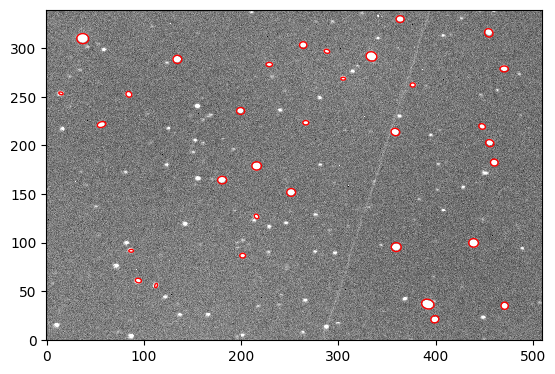

33


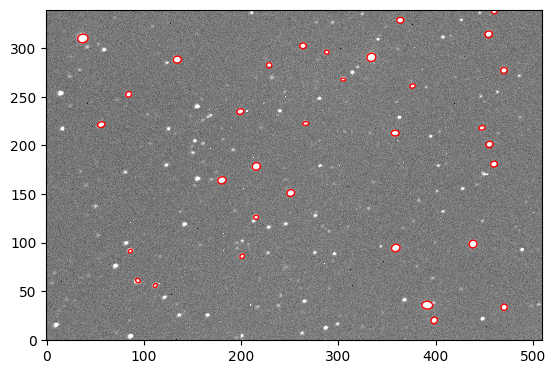

33


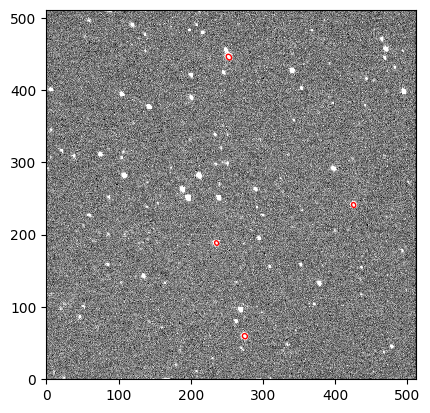

4


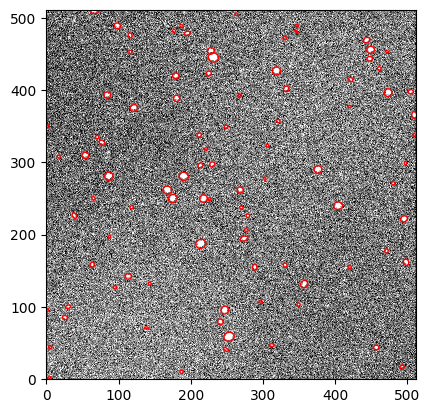

92


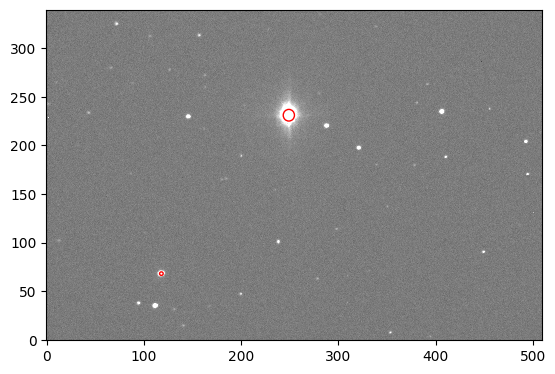

2


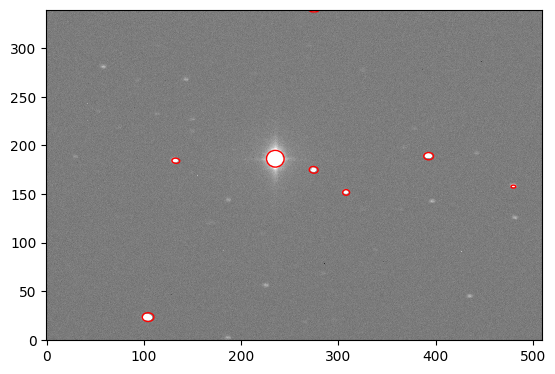

8


In [317]:
#august
position_aug_1 = star_counter_position(data_aug_1,8000)
position_aug_180 = star_counter_position(data_aug_180,4000)

#v404cyg
position_v404_1 = star_counter_position(data_v404_1,550)
position_v404_414 = star_counter_position(data_v404_414,485)

#july
position_jul_1 = star_counter_position(data_jul_1,10000)
position_jul_643 = star_counter_position(data_jul_643,1000)

In [234]:
#tries to find the same star in both exposures by taking the smallest distance between a star in one exposure and the other
def shift_calc(position1,position2):
    min_dist = []
    index = {}
    for j in range(len(position1)):
        temp = []
        for k in range(len(position2)):
    
            distance = np.sqrt((position1['x'][j]-position2['x'][k])**2+(position1['y'][j]-position2['y'][k])**2)
    
            temp.append(distance)
    
    
        #take the minimum distance value per star
        min_dist.append(np.min(temp))
        
        #finds the index of the min value
        index.update({j:min(range(len(temp)), key=temp.__getitem__)})
    
    horiz_shift = []
    vert_shift = []

    #find the x and y difference between the closest detected star for all stars in the reference image
    for key, value in index.items():
    
        horiz = position1['x'][key] - position2['x'][value]
    
        horiz_shift.append(horiz)
    
        vert = position1['y'][key] - position2['y'][value]
    
        vert_shift.append(vert)

    shift_xy = [horiz_shift,vert_shift]

    return shift_xy,index

In [337]:
#calcualtes the offset in (x,y) position between two exposures
def calculate_offset(position1,position2):
    shift_xy,index = shift_calc(position1,position2)

    horiz_avg = shift_function(shift_xy[0],1)
    vert_avg = shift_function(shift_xy[1],1)

    return horiz_avg,vert_avg

aug_ofst = calculate_offset(position_aug_1,position_aug_180)
v404_ofst = calculate_offset(position_v404_1,position_v404_414)
jul_ofst = calculate_offset(position_jul_1,position_jul_643)

In [353]:
#prints the (x,y) offset of the last exposure compared to the first
print(aug_ofst)
print()
print(v404_ofst)
print()
print(jul_ofst)

(0.306559607520506, 0.8314899253375977)

(21.854776462287504, 1.015456825064625)

(13.670340774588169, 44.725240494921)


In [367]:
#moves an exposure in the (x,y) directions based on the calculated offset
def offset_image(image2,image_ofst):
    #positive shift in the x direction means it needs to move to the right
    #positive shift in the y direction means it needs to move up
    shifted_x = shift(np.rot90(image2),int(-image_ofst[0]), fill_value=0)
    image2_x = np.rot90(shifted_x,-1)
    image2_shifted = shift((image2_x),int(image_ofst[1]), fill_value=0)

    return image2_shifted

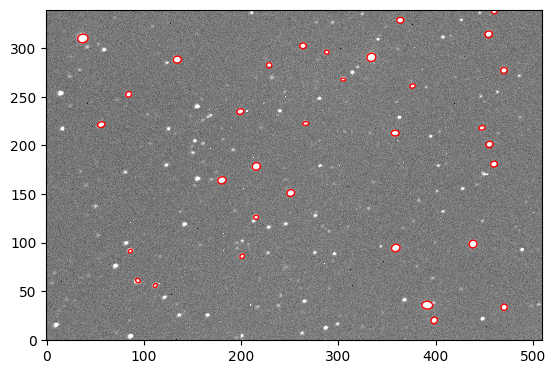

33


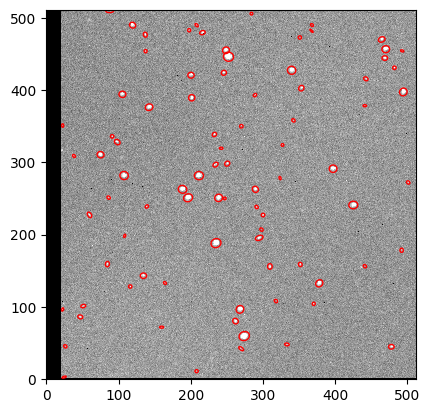

85


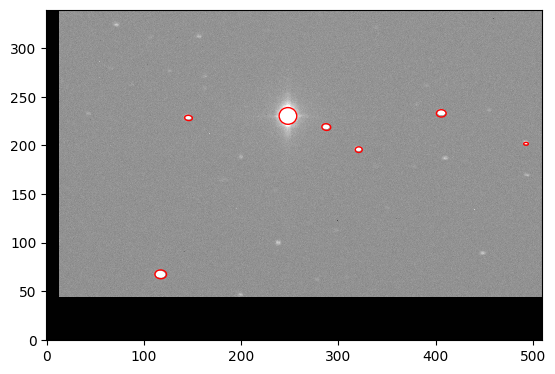

7


In [371]:
#dispalys the shifted images
ofst_aug_180 = offset_image(data_aug_180,aug_ofst)
shifted_aug_180 = star_counter_position(ofst_aug_180,4000)

ofst_v404_414 = offset_image(data_v404_414,v404_ofst)
shifted_v404_414 = star_counter_position(ofst_v404_414,485)

ofst_jul_643 = offset_image(data_jul_643,jul_ofst)
shifted_jul_643 = star_counter_position(ofst_jul_643,1000)

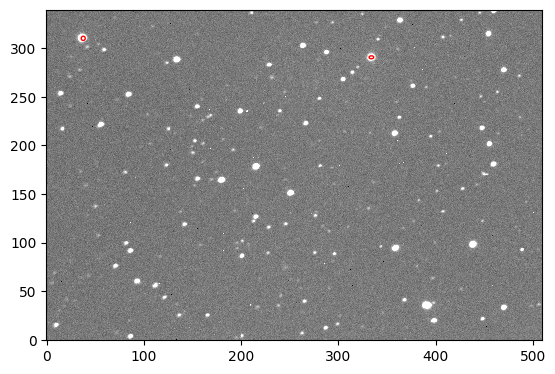

2


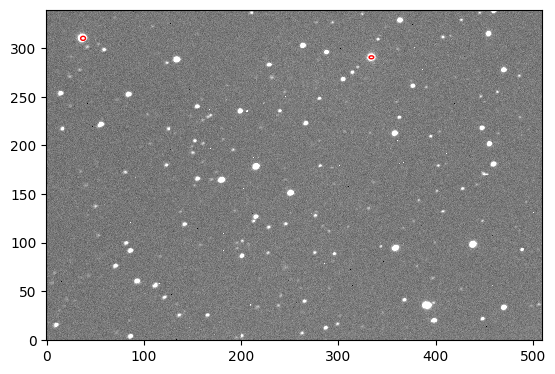

2


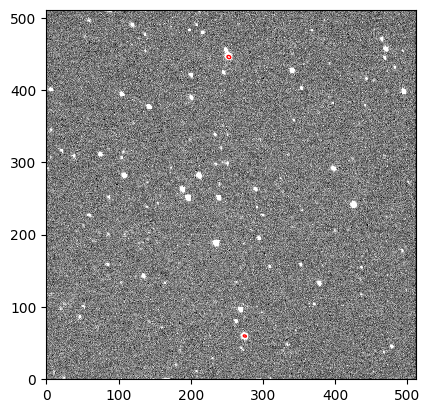

2


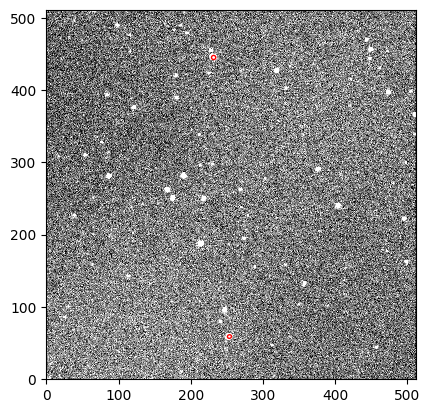

2


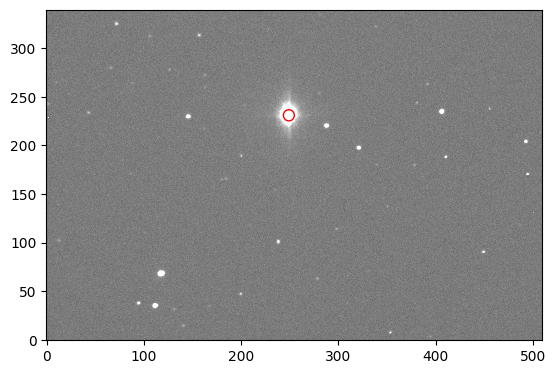

1


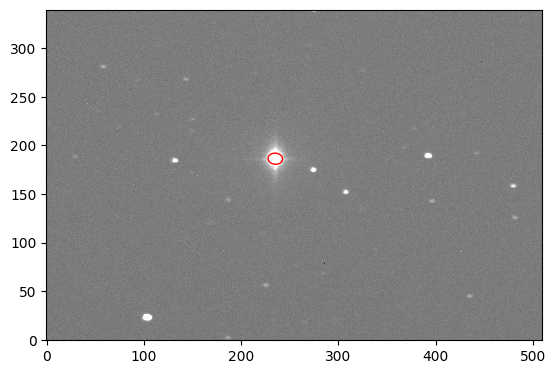

1


In [348]:
#manually checks if the calcualted offsets are correct by finding the same stars in two exposures and comparing their position
#august
manual_aug_1 = star_counter_position(data_aug,21000)
manual_aug_180 = star_counter_position(data_aug,20000)

#v404cyg
manual_v404_1 = star_counter_position(data_v404_1,1400)
manual_v404_414 = star_counter_position(data_v404_414,1400)

#july
manual_jul_1 = star_counter_position(data_jul_1,11000)
manual_jul_643 = star_counter_position(data_jul_643,8000)

In [351]:
#finds the difference from the same two stars' position in the manual check and subtracts that from the calcualted offset in position
def manual_check(position1,position2,calculated_offset):
    x_dif = position1['x'] - position2['x']    
    mean_x = np.mean(x_dif)
    
    y_dif = position1['y'] - position2['y']    
    mean_y = np.mean(y_dif)
    
    manual_xdif = calculated_offset[0] - mean_x
    manual_ydif = calculated_offset[1] - mean_y
    
    print("Difference between manual offset and calculated offset in the x direction  =",manual_xdif)
    print("Difference between manual offset and calculated offset in the y direction  =",manual_ydif)
    print()

In [352]:
manual_check(manual_aug_1,manual_aug_180,aug_ofst)
manual_check(manual_v404_1,manual_v404_414,v404_ofst)
manual_check(manual_jul_1,manual_jul_643,jul_ofst)

Difference between manual offset and calculated offset in the x direction  = 0.21917559998002384
Difference between manual offset and calculated offset in the y direction  = 0.834094953127822

Difference between manual offset and calculated offset in the x direction  = 0.6447550878879156
Difference between manual offset and calculated offset in the y direction  = 0.3299026458385441

Difference between manual offset and calculated offset in the x direction  = -0.2648408475294559
Difference between manual offset and calculated offset in the y direction  = 0.06401028278293808

